In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
import fnmatch
import matplotlib.pyplot as plt
from functools import reduce
from bs4 import BeautifulSoup
import requests
import osmnx as ox

import networkx as nx
import copy
import matplotlib
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from osgeo import gdal
import importlib

import API_KEY
import helper_functions.utils as utils
import helper_functions.serviceArea
import helper_functions.amenities_dict
import helper_functions.OneMapAPI
import helper_functions.LocationIqAPI
importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.amenities_dict)
importlib.reload(helper_functions.OneMapAPI)
importlib.reload(API_KEY)
importlib.reload(helper_functions.LocationIqAPI)

import helper_functions.serviceArea as serviceArea
import helper_functions.amenities_dict as amenities_dict
import helper_functions.plot_utils as plot_utils
import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.LocationIqAPI as LocationIqAPI
from API_KEY import get_OneMap_token
import API_KEY

# Import road network

In [3]:
G_car = ox.load_graphml(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\V3 analysis\data\SG_car_network.graphml")

# Import planning area

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['BEDOK', 'BOON LAY', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG',
       'BUKIT TIMAH', 'CENTRAL WATER CATCHMENT', 'CHANGI',
       'CHOA CHU KANG', 'CLEMENTI', 'HOUGANG', 'JURONG EAST',
       'JURONG WEST', 'PASIR RIS', 'PIONEER', 'PUNGGOL', 'QUEENSTOWN',
       'SELETAR', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'KALLANG',
       'LIM CHU KANG', 'NORTH-EASTERN ISLANDS', 'NOVENA', 'SIMPANG',
       'SOUTHERN ISLANDS', 'SUNGEI KADUT', 'TOA PAYOH', 'TUAS',
       'WESTERN ISLANDS', 'WESTERN WATER CATCHMENT', 'WOODLANDS',
       'RIVER VALLEY', 'ROCHOR', 'SINGAPORE RIVER', 'STRAITS VIEW',
       'CHANGI BAY', 'MARINE PARADE', 'DOWNTOWN CORE', 'MARINA EAST',
       'MARINA SOUTH', 'MUSEUM', 'NEWTON', 'ORCHARD', 'OUTRAM',
       'TAMPINES', 'TANGLIN', 'TENGAH', 'MANDAI', 'BISHAN', 'ANG MO KIO',
       'GEYLANG', 'PAYA LEBAR', 'YISHUN'], dtype=object)

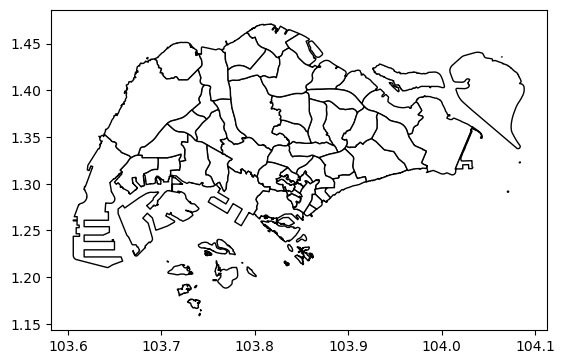

In [4]:
planningArea_noSea = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Masterplan\MasterPlan2019PlanningAreaBoundaryNoSea.geojson")

def extract_html_tags(row):
    html_content = row["Description"]
    soup = BeautifulSoup(html_content,"html.parser")
    ths = soup.find_all('th')
    tds = soup.find_all('td')
    column_names = []
    column_values = []
    for th in ths:
        column_names.append(th.get_text())
    for td in tds:
        column_values.append(td.get_text())
    column_names = column_names[1:] # remove the first "Attribute"
    return pd.Series({k:v for k,v in zip(column_names,column_values)})
# column_names, _ = extract_html_tags(planningArea_noSea.iloc[0,1])
planningArea_shp = planningArea_noSea.join(planningArea_noSea.apply(extract_html_tags,axis=1))
print(type(planningArea_shp))
planningArea_shp.plot(fc='white',ec='k')
planningArea_shp['PLN_AREA_N'].unique()

# Import subzone

<class 'geopandas.geodataframe.GeoDataFrame'>


,Name,Description,geometry,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D
0,kml_1,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.81454 1.28239 0, 103.81774 1.2...",12,DEPOT ROAD,BMSZ12,N,BUKIT MERAH,BM,CENTRAL REGION,CR,C22DED671DE2A940,20191223152313
1,kml_2,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.82209 1.28049 0, 103.8221 1.28...",2,BUKIT MERAH,BMSZ02,N,BUKIT MERAH,BM,CENTRAL REGION,CR,085EF219A5A1AEAD,20191223152313
2,kml_3,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.84375 1.28508 0, 103.844 1.284...",3,CHINATOWN,OTSZ03,Y,OUTRAM,OT,CENTRAL REGION,CR,EF2B9A91AF49E025,20191223152313
3,kml_4,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.84962 1.28412 0, 103.84955 1.2...",4,PHILLIP,DTSZ04,Y,DOWNTOWN CORE,DT,CENTRAL REGION,CR,615D4EDDEF809F8E,20191223152313
4,kml_5,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.85253 1.28617 0, 103.85253 1.2...",5,RAFFLES PLACE,DTSZ05,Y,DOWNTOWN CORE,DT,CENTRAL REGION,CR,72107B11807074F4,20191223152313


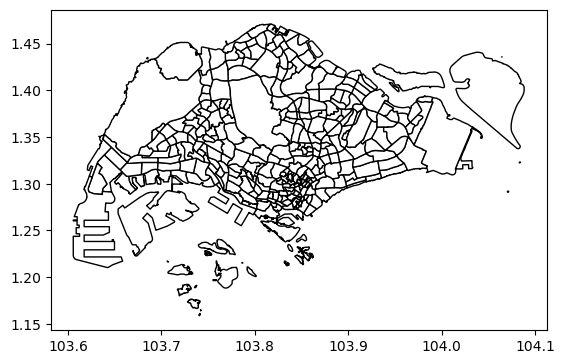

In [5]:
subzone_noSea = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Masterplan\MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson")

def extract_html_tags(row):
    html_content = row["Description"]
    soup = BeautifulSoup(html_content,"html.parser")
    ths = soup.find_all('th')
    tds = soup.find_all('td')
    column_names = []
    column_values = []
    for th in ths:
        column_names.append(th.get_text())
    for td in tds:
        column_values.append(td.get_text())
    column_names = column_names[1:] # remove the first "Attribute"
    return pd.Series({k:v for k,v in zip(column_names,column_values)})
# column_names, _ = extract_html_tags(planningArea_noSea.iloc[0,1])
subzone_shp = subzone_noSea.join(subzone_noSea.apply(extract_html_tags,axis=1))
print(type(subzone_shp))
subzone_shp.plot(fc='white',ec='k')
subzone_shp.head()

# Import DEM
- FABDEM (30m spatial resolution)

To check if higher elevation has lower flood risk, and also fetches higher property prices

In [6]:
SG_DEM = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\FABDEM_SG_30m\FABDEM_SG_30m_Clipped.tif"
SG_DEM_raster = gdal.Open(SG_DEM)
print("Projection is {}".format(SG_DEM_raster.GetProjection()))
# get geotransform
geotransform_SG_DEM_raster = SG_DEM_raster.GetGeoTransform()

band = SG_DEM_raster.GetRasterBand(1)
print("Band Type={}".format(gdal.GetDataTypeName(band.DataType)))

min_ = band.GetMinimum()
max_ = band.GetMaximum()
if not min_ or not max_:
    (min_,max_) = band.ComputeRasterMinMax(True)
print("Min={:.3f}, Max={:.3f}".format(min_,max_))

# read as array
SG_DEM_raster_arr = np.array(SG_DEM_raster.GetRasterBand(1).ReadAsArray())

def get_coords(dx,dy, geotransform):
    """" get coordinate with any array index
    Args:
        dx (int): column pixel from the origin (upper left corner)
        dy (int): row pixel from the origin (upper left corner)
    """
    # origin
    px = geotransform[0]
    py = geotransform[3]
    # pixel size
    rx = geotransform[1]
    ry = geotransform[5]
    x = dx*rx + px
    y = dy*ry + py
    return y,x

def get_DEM_value(lon,lat,geotransform):
    """
    Returns:
        dx (int): column pixel from the origin (upper left corner)
        dy (int): row pixel from the origin (upper left corner)
    """
    # origin
    px = geotransform[0]
    py = geotransform[3]
    # pixel size
    rx = geotransform[1]
    ry = geotransform[5]
    dx = (lon -px)/rx
    dy = (lat - py)/ry
    return round(dx), round(dy)

# bukit timah elevation validation (163.63m)
dx, dy = get_DEM_value(103.7763750,1.3546806,geotransform_SG_DEM_raster)
SG_DEM_raster_arr[dy, dx]

Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Band Type=Float32
Min=-37.000, Max=180.180


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


np.float32(167.37)

# Import drainage works on roads

In [7]:
drainage_works = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\Exported_Data\drainage_works_roads_2012_2024.csv")
print("length of df: ",len(drainage_works))
drainage_works = drainage_works.dropna(subset=["LATITUDE","LONGITUDE"])
print("length of df: ",len(drainage_works))
print(drainage_works.dtypes)
# # rename similar types of drainage works
# def recategorise_drainage_works(text):
#     text = text.strip()
#     # Check if the entire string matches "drainage work(s)"
#     if re.fullmatch(r"drainage\s+works?", text, flags=re.IGNORECASE):
#         cat = "Drainage Work"
#     elif re.fullmatch(r"road\s+raising(\s+works?)?", text, flags=re.IGNORECASE):
#         cat = "Road Raising"
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+In\s+(.*)(EUP)",text, flags=re.IGNORECASE):
#         cat = 'Improvement to Roadside Drains In EUP'
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+and\s+Watermain\s+Replacement(.*)$",text, flags=re.IGNORECASE):
#         cat = "Improvement to Roadside Drains and Watermain Replacement"
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains(.*)$",text, flags=re.IGNORECASE):
#         cat = "Improvement to Roadside Drains"
#     else:
#         cat = text
#     return cat
# drainage_works["work_categories"] = drainage_works["work_types"].apply(lambda x: recategorise_drainage_works(x))

drainage_works.head()

length of df:  596
length of df:  596
S/N                     int64
Location               object
Date                   object
Status                 object
Year                    int64
Month                   int64
work_types             object
location               object
locations              object
SEARCHVAL              object
BLK_NO                 object
ROAD_NAME              object
BUILDING               object
ADDRESS                object
POSTAL                 object
X                     float64
Y                     float64
LATITUDE              float64
LONGITUDE             float64
number_of_searches    float64
work_categories        object
dtype: object


,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,...,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works


### Plot drainage works

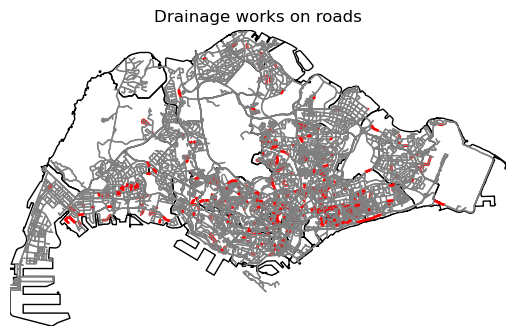

In [8]:
planningArea_shp_mainland = planningArea_shp[~planningArea_shp["PLN_AREA_N"].str.contains("ISLAND")]
minx = planningArea_shp_mainland.bounds["minx"].min()
miny = planningArea_shp_mainland.bounds["miny"].min()
maxx = planningArea_shp_mainland.bounds["maxx"].max()
maxy = planningArea_shp_mainland.bounds["maxy"].max()

bbox = (minx, miny, maxx - 4e-4*maxx, maxy)

def identify_road_with_drainage_works(G,drainage_works, plot=True,ax=None,**kwargs):
    """                           
    Args:
        G (MultiDiGraph): graph of walking or driving network
        drainage_works (pd.DataFrame): dataframe that describes the type and location of drainage works
    Return:
        gpd: edges corresponding to drainage works location
    """
    lat = drainage_works["LATITUDE"]
    lon = drainage_works["LONGITUDE"]
    edges_drain = list(ox.nearest_edges(G,lon,lat))

    if plot:
        ec = ["red" if e in edges_drain else "grey" for e in G.edges(keys=True)]
        lw = [2 if e in edges_drain else 1 for e in G.edges(keys=True)]
        fig, ax = ox.plot_graph(
            G,
            ax=ax,
            node_size=0,
            node_alpha=0.8,
            edge_linewidth=lw,
            edge_color=ec,
            show=False,
            close=False,
            bgcolor="white",
            **kwargs
        )

    # get the polyline of the roads that has drainage works
    edges = ox.graph_to_gdfs(G,nodes=False,edges=True)
    edges_geometry = edges.loc[edges_drain,["geometry"]].reset_index()
    # append geometry to drainage works
    drainage_works_copy = copy.deepcopy(drainage_works)
    drainage_works_copy[edges_geometry.columns.to_list()] = edges_geometry
    drainage_works_copy = gpd.GeoDataFrame(drainage_works_copy,geometry=drainage_works_copy["geometry"])
    return drainage_works_copy

fig, ax = plt.subplots(1,1)
planningArea_shp_mainland.plot(ax=ax,fc="None",ec="k")
drainage_works_geometry = identify_road_with_drainage_works(G_car,drainage_works,plot=True,ax=ax,bbox=bbox)
ax.set_title("Drainage works on roads")
save_fp = os.path.join(r"Exported_Data\exported_figures","drainage_works_on_road.png")
# plt.savefig(save_fp, bbox_inches = 'tight')
plt.show()

<Axes: >

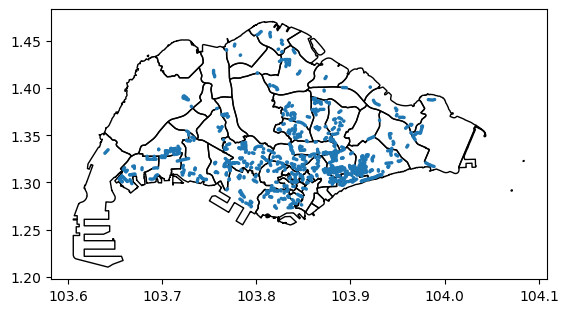

In [ ]:
def buffer_road(drainage_works_geometry,buffer=200):
    """ 
    Args:
        drainage_works_geometry (gpd): drainage works in linestring
        buffer (float): buffer around the geometry in metres
    Returns:
        polygon gpd
    """
    # project to meters UTM
    crs = drainage_works_geometry.crs
    # reproject to something that is in meters projection
    reproj_drainage_works = drainage_works_geometry.to_crs({'proj':'cea'})#.to_crs(3003)
    drainage_buffer = reproj_drainage_works.buffer(buffer)
    drainage_buffer = drainage_buffer.to_crs(crs)
    drainage_works_copy = copy.deepcopy(drainage_works_geometry)
    drainage_works_copy["geometry"] = drainage_buffer
    return drainage_works_copy

drainage_works_buffer = buffer_road(drainage_works_geometry,buffer=200)
ax = planningArea_shp_mainland.plot(fc="None",ec="k")
drainage_works_buffer.plot(ax=ax)
# drainage_works_buffer.to_file(os.path.join(r"Exported_Data","drainage_works_buffer200m.shp"),driver='ESRI Shapefile')

# Import drainage network

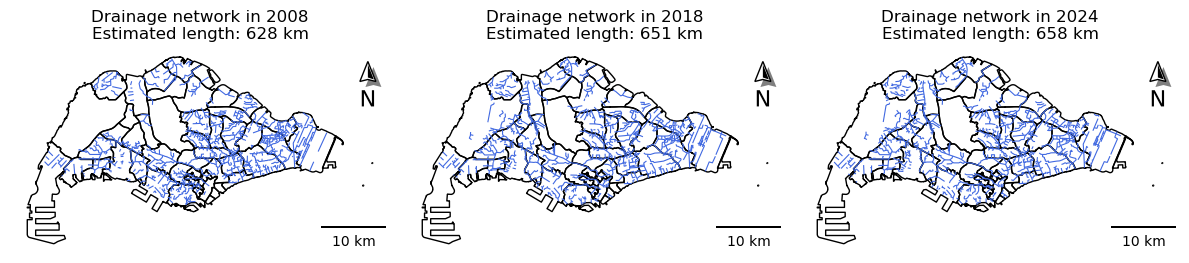

In [201]:
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\BlueMapShpFiles"
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251027 BlueMapShpFiles"
drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251110 Blue Map layers"
# drain_undated = "UndatedSGDrainage.shp"
drain_2008 = "2008Bluemap.shp"
drain_2018 = "2018Bluemap.shp"
drain_2024 = "2024Bluemap.shp"

def plot_drains(fp,planningArea,ax=None,lw=2):
    planningArea = planningArea[~planningArea['PLN_AREA_N'].str.contains("ISLAND")]
    # convert the dataset to a coordinate system which uses meters e.g. UTM work in metres
    planningArea = planningArea.to_crs(planningArea.estimate_utm_crs())
    gdf = gpd.read_file(fp)
    gdf = gdf.to_crs(planningArea.crs)
    gdf = gpd.clip(gdf,planningArea)
    # calculate total length
    drain_length = int(gdf['geometry'].length.sum()/1000) # m to km
    ax = planningArea.plot(fc="None",ec="k",ax=ax)
    gdf.plot(ax=ax,lw=lw,color="royalblue")
    # add scale
    ax.set_aspect(1)
    scalebar = ScaleBar(1, "m",location="lower right")
    # add north arrow
    north_arrow(
        ax, location="upper right", rotation={"crs": planningArea.crs, "reference": "center"},
        scale=0.2
    )
    ax.add_artist(scalebar)
    if ax is None:
        plt.show()
    
    return drain_length

fig, axes = plt.subplots(1,3,figsize=(12,6))
for ax, drain_fp,title in zip(axes.flatten(),[drain_2008,drain_2018,drain_2024],
                              ["2008","2018","2024"]):
    drain_length = plot_drains(os.path.join(drain_dir,drain_fp),planningArea_shp,ax=ax,lw=0.8)
    ax.set_title(f"Drainage network in {title}\nEstimated length: {drain_length} km")
    ax.axis('off')

save_dir = r"data\simulatedExtremePluvialFlood\exported_figures"
save_fp = os.path.join(save_dir,"sg_drainage_with_time.svg")
plt.tight_layout()
# plt.savefig(save_fp, bbox_inches="tight")
plt.show()

## Calculate drainage density
- calculate length of drain
- calculate area of planning area polygon
- Calculate drainage density: length of drain/planning area (km/km2)

In [207]:
def get_drainage_density(fp,planningArea, plot=False,ax=None,save_fp=None):
    """
    calculate drainage density (km/km2) for each planning area
    Args:
        fp (str): filepth to the drainage network
        planningArea (gpd.GeoDataFrame): 
    """
    planningArea_copy = copy.deepcopy(planningArea)
    planningArea_copy = planningArea_copy[~planningArea_copy['PLN_AREA_N'].str.contains("ISLAND")]
    # convert the dataset to a coordinate system which uses meters e.g. UTM work in metres
    planningArea_copy = planningArea_copy.to_crs(planningArea_copy.estimate_utm_crs())
    gdf = gpd.read_file(fp)
    gdf = gdf.to_crs(planningArea_copy.crs)
    # gdf = gpd.clip(gdf,planningArea_copy)
    # planningArea[planningArea['geometry'].geom_type != "Polygon"]
    # calculate length of drainage in each planning area polygon
    planningArea_copy["drainage_length_km"] = [gpd.clip(gdf,s)['geometry'].length.sum()/1000 for s in planningArea_copy["geometry"].values]
    planningArea_copy["Area_km2"] = planningArea_copy["geometry"].area/1e6
    planningArea_copy["drainage_density (km/km2)"] = planningArea_copy["drainage_length_km"]/planningArea_copy["Area_km2"]
    if plot:
        planningArea_copy.plot(column="drainage_density (km/km2)",cmap='OrRd',ec="k",
                               ax=ax,
                               legend=True,
                               legend_kwds={"label": r"Drainage density ($km/km^2$)", 
                                            "orientation": "horizontal"},
                               missing_kwds={
                                    "color": "lightgrey",
                                    "edgecolor": "black",
                                    "hatch": "///",
                                    "label": "Missing data"}
                                    )
    
    if save_fp is not None:
        planningArea_copy.to_csv(save_fp,index=False)
        
    return planningArea_copy

year_drainage_density = dict()
for drain_fp in [drain_2008,drain_2018,drain_2024]:
    year_drainage_density[drain_fp] = get_drainage_density(os.path.join(drain_dir,drain_fp),planningArea_shp, plot = False)

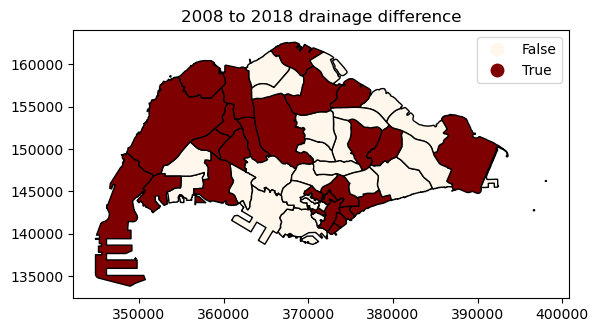

In [215]:
def drainage_density_difference(drain_before,drain_after,plot=True,ax=None,title=""):
    """    
    calculate difference in drainage density between years                         
    Args:
        drain_before (pd.DataFrame):
        drain_after (pd.DataFrame):
    """
    drain_after["drainage_density_difference"] = drain_after["drainage_density (km/km2)"] - drain_before["drainage_density (km/km2)"]
    # positive if there is an increase in drainage density, -ve if there is a decrease
    drain_after["drainage_density_direction"] = drain_after["drainage_density_difference"]>0
    if plot:
        ax = drain_after.plot(column="drainage_density_direction",cmap='OrRd',ec="k",
                               ax=ax,
                               legend=True)
        ax.set_title(title)
    return 

drainage_density_difference(year_drainage_density["2008Bluemap.shp"],
                            year_drainage_density["2018Bluemap.shp"],
                            title="2008 to 2018 drainage difference",
                            plot=True,ax=None)

# Correct completed drainage projects (2012-2024) [Analysis]

In [92]:
drainage_projects = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\Drainage plans\PUB_All_Drainage_Projects_2012_2024.csv")
drainage_projects_completed = drainage_projects[drainage_projects["Status"]=="Completed"]
drainage_projects_completed["Date"] = pd.to_datetime(drainage_projects_completed["Date"],format="%b-%y")
drainage_projects_completed["Year"] = drainage_projects_completed["Date"].dt.year
drainage_projects_completed["Month"] = drainage_projects_completed["Date"].dt.month

# separate project type and location

def extract_road_names(text):
    
    pattern = r"^(.*?)\s*(?:\bat\b|[-–—@])\s*(.*)$"

    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        work_types = match.group(1).strip()
        location = match.group(2).strip()
    else:
        pattern = r"^(.*?)\s*\b(?:in|to|along|of|for)\s*(.*)$"

        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            work_types = match.group(1).strip()
            location = match.group(2).strip()
        else:
            work_types = None
            location = text
    
    return pd.Series({"work_types":work_types,"location":location},index=["work_types","location"])

drainage_projects_completed[["work_types","location"]] = drainage_projects_completed["Location"].apply(lambda x: extract_road_names(x))

# Find multiple roads and split them if applicable

def extract_multiple_road_names(text):

    # Remove extra whitespace
    text = text.strip()

    def split_separator(s):
        # Otherwise, split by common separators (/, &, to, ,)
        pattern = r'\s*(?:/|&|,|\bto\b)\s*'
        parts = re.split(pattern, s, flags=re.IGNORECASE)
        return [p.strip() for p in parts if p.strip()]
    
    # 1. Handle parentheses first — extract before and inside ()
    bracket_match = re.match(r'^(.*?)\s*\(([^)]+)\)\s*$', text)
    if bracket_match:
        before = bracket_match.group(1).strip()
        inside = bracket_match.group(2).strip()
        
        return [before] + split_separator(inside)

    return split_separator(text)

drainage_projects_completed["locations"] = drainage_projects_completed["location"].apply(lambda x: extract_multiple_road_names(x))
drainage_projects_completed = drainage_projects_completed.explode("locations")

drainage_projects_completed

C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drainage_projects_completed["Date"] = pd.to_datetime(drainage_projects_completed["Date"],format="%b-%y")
C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drainage_projects_completed["Year"] = drainage_projects_completed["Date"].dt.year
C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:5: SettingWithCopyWarning: 
A value is

,S/N,Location,Date,Status,Year,Month,work_types,location,locations
0,1,Development of Kallang River – Bishan-Ang Mo K...,2012-01-01,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park
1,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road
2,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road
3,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden
...,...,...,...,...,...,...,...,...,...
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road
438,439,Drainage work at Jurong East St 32,2023-07-01,Completed,2023,7,Drainage work,Jurong East St 32,Jurong East St 32


Get coordinates of drainage works location

In [93]:
def get_road_location(road,headers,index=['SEARCHVAL','BLK_NO','ROAD_NAME','BUILDING','ADDRESS','POSTAL','X','Y','LATITUDE','LONGITUDE']):
    try:
        searches = OneMapAPI.get_coordinates_from_location(road, headers)
        location_dict = searches[0]
        location_dict["number_of_searches"] = len(searches)
    except:
        index.append("number_of_searches")
        location_dict = {k:None for k in index}
    
    
    return pd.Series(location_dict, index=list(location_dict))

headers = OneMapAPI.generate_OneMap_headers()
drainage_locations = drainage_projects_completed["locations"].apply(lambda x: get_road_location(x,headers))
drainage_locations

,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,BISHAN - ANG MO KIO PARK (POND GARDENS),,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.5993566066,38579.1553769931,1.36517069591469,103.83629822663,2.0
1,AH HOOD ROAD,,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.5309455593,34437.90693839,1.32771861428245,103.846855352744,2.0
2,BALMORAL ROAD,,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.8432115718,32837.3066058314,1.31324355521211,103.830181342875,1.0
3,BEDOK LANE,,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.7222646378,34619.5605429257,1.32935743601885,103.948251313101,1.0
4,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
...,...,...,...,...,...,...,...,...,...,...,...
436,None,None,None,None,None,None,None,None,None,None,NaN
437,KRAMAT LANE,,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.6459057741,31481.2032468384,1.30097931805497,103.84227389462,1.0
437,CAVENAGH ROAD,,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.5044461648,32268.6550906781,1.30809356579841,103.84213845629,1.0
438,JURONG EAST STREET 32,,JURONG EAST STREET 32,NIL,JURONG EAST STREET 32,NIL,16927.0841891803,36565.146363027,1.34694849545159,103.733825383102,1.0


In [94]:
drainage_projects_completed = pd.concat([drainage_projects_completed,drainage_locations],axis=1)
drainage_projects_completed.to_csv(r"Exported_Data\drainage_works_2012_2024.csv",index=False)
drainage_projects_completed

,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,1,Development of Kallang River – Bishan-Ang Mo K...,2012-01-01,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.5993566066,38579.1553769931,1.36517069591469,103.83629822663,2.0
1,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.5309455593,34437.90693839,1.32771861428245,103.846855352744,2.0
2,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.8432115718,32837.3066058314,1.31324355521211,103.830181342875,1.0
3,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.7222646378,34619.5605429257,1.32935743601885,103.948251313101,1.0
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate,None,None,None,None,None,None,None,None,None,None,NaN
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.6459057741,31481.2032468384,1.30097931805497,103.84227389462,1.0
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.5044461648,32268.6550906781,1.30809356579841,103.84213845629,1.0
438,439,Drainage work at Jurong East St 32,2023-07-01,Completed,2023,7,Drainage work,Jurong East St 32,Jurong East St 32,JURONG EAST STREET 32,,JURONG EAST STREET 32,NIL,JURONG EAST STREET 32,NIL,16927.0841891803,36565.146363027,1.34694849545159,103.733825383102,1.0


In [154]:
def get_location_IQ(location,
                    index=['SEARCHVAL','BLK_NO','ROAD_NAME','BUILDING','ADDRESS','POSTAL','X','Y','LATITUDE','LONGITUDE']):
    searches = LocationIqAPI.get_coordinates_from_location(location)

    location_dict = {k:None for k in index}
    try:
        response = searches[0]
        location_dict['SEARCHVAL'] = response['display_name']
        location_dict['LATITUDE'] = response['lat']
        location_dict['LONGITUDE'] = response['lon']
        location_dict["number_of_searches"] = len(searches)
    except:
        location_dict["number_of_searches"] = None
    
    return pd.Series(location_dict,index=list(location_dict))
    
    
x = get_location_IQ("Phoenix, Singapore, Singapore")
x

SEARCHVAL             Phoenix, 40, Choa Chu Kang Road, Teck Whye, Ch...
BLK_NO                                                             None
ROAD_NAME                                                          None
BUILDING                                                           None
ADDRESS                                                            None
POSTAL                                                             None
X                                                                  None
Y                                                                  None
LATITUDE                                                      1.3786164
LONGITUDE                                                    103.758008
number_of_searches                                                    2
dtype: object

In [165]:
lorongGeylang = LocationIqAPI.get_coordinates_from_location("Lorong 42 Geylang, Singapore, Singapore")
lorongGeylang

[{'place_id': '251031082',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '46342760',
  'boundingbox': ['1.3143543', '1.3146876', '103.8902132', '103.8902533'],
  'lat': '1.3146876',
  'lon': '103.8902132',
  'display_name': 'Lorong 42 Geylang, Geylang, Southeast, Singapore, 389604, Central Region, Singapore',
  'class': 'highway',
  'type': 'residential',
  'importance': 0.5834176615548942},
 {'place_id': '250993455',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '1015739635',
  'boundingbox': ['1.3140305', '1.3141815', '103.8902879', '103.8903376'],
  'lat': '1.3140473',
  'lon': '103.8903147',
  'display_name': 'Lorong 42 Geylang, Geylang, Southeast, Singapore, 398024, Central Region, Singapore',
  'class': 'highway',
  'type': 'service',
  'importance': 0.5700843282215609},
 {'place_id': '251351702',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '647095214',
  'boundingb

In [160]:
problematic_rows = drainage_projects_completed[((drainage_projects_completed['number_of_searches']>2) | (drainage_projects_completed['number_of_searches'].isna()))]
problematic_rows

,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
8,9,Drainage Works at Ewe Boon Rd Areas,2012-11-01,Completed,2012,11,Drainage Works,Ewe Boon Rd Areas,Ewe Boon Rd Areas,None,None,None,None,None,None,None,None,None,None,NaN
10,11,Improvement to Roadside Drains In Estate Upgra...,2012-11-01,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Phoenix,Phoenix,PHOENIX HEIGHTS,10,PHOENIX GARDEN,PHOENIX HEIGHTS,10 PHOENIX GARDEN PHOENIX HEIGHTS SINGAPORE 66...,668278,19662.3186762407,39840.217556119,1.37657410885303,103.758398456974,10.0
12,13,Drainage Works at Lorong 102 to 106 Changi Rd,2013-01-01,Completed,2013,1,Drainage Works,Lorong 102 to 106 Changi Rd,106 Changi Rd,1063A UPPER CHANGI ROAD NORTH SINGAPORE 507704,1063A,UPPER CHANGI ROAD NORTH,NIL,1063A UPPER CHANGI ROAD NORTH SINGAPORE 507704,507704,43773.0555428769,38628.6779148001,1.36561435805998,103.975050188576,9.0
18,19,Drainage Works at Dunearn Rd/ Hillcrest Rd jun...,2013-01-01,Completed,2013,1,Drainage Works,Dunearn Rd/ Hillcrest Rd junction,Dunearn Rd,DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),,NIL,DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),NIL,26907.0627031503,33764.3403379712,1.32162720092152,103.823497961309,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,431,Improvement to Bayshore Park Outlet Drain (ECP...,2023-03-01,Completed,2023,3,Improvement,Bayshore Park Outlet Drain (ECP Service Road t...,Bayshore Park Outlet Drain,None,None,None,None,None,None,None,None,None,None,NaN
430,431,Improvement to Bayshore Park Outlet Drain (ECP...,2023-03-01,Completed,2023,3,Improvement,Bayshore Park Outlet Drain (ECP Service Road t...,the Sea,CHURCH OF OUR LADY STAR OF THE SEA,10,YISHUN STREET 22,CHURCH OF OUR LADY STAR OF THE SEA,10 YISHUN STREET 22 CHURCH OF OUR LADY STAR OF...,768579,28515.1892367527,46549.7553463355,1.43725393340129,103.837948048756,10.0
433,434,Drainage work at Sennett Estate,2023-10-01,Completed,2023,10,Drainage work,Sennett Estate,Sennett Estate,SENNETT ESTATE,8,KWONG AVENUE,SENNETT ESTATE,8 KWONG AVENUE SENNETT ESTATE SINGAPORE 348882,348882,32218.0471483897,34727.6016367543,1.33033832214633,103.871220086251,10.0
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate,None,None,None,None,None,None,None,None,None,None,NaN


In [199]:
# OneMapAPI.get_coordinates_from_location("stadium cres", headers)
get_location_IQ("woodlands avenue 5, Singapore, Singapore")

SEARCHVAL             Woodlands Avenue 5, Woodgrove, Woodlands, Nort...
BLK_NO                                                             None
ROAD_NAME                                                          None
BUILDING                                                           None
ADDRESS                                                            None
POSTAL                                                             None
X                                                                  None
Y                                                                  None
LATITUDE                                                      1.4352105
LONGITUDE                                                   103.7832869
number_of_searches                                                   10
dtype: object

In [197]:
problematic_rows0 = pd.read_csv(r"Exported_Data\locations_problem.csv")
headers = OneMapAPI.generate_OneMap_headers()
problematic_rows0[['SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE', 'LONGITUDE',"number_of_searches"]] = problematic_rows0["locations"].apply(lambda x: get_road_location(x,headers))
problematic_rows0.dropna(subset=["number_of_searches"]).to_csv(r"Exported_Data\drainage_works_OneMap.csv",index=False)
problematic_rows0

,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,Bukit Timah Road,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,,NIL,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,NIL,22941.8794712201,37287.9545795117,1.35349310900464,103.787868117719,10.0
1,Holland Green,HOLLAND GREEN,13,HOLLAND GREEN,HOLLAND GREEN,13 HOLLAND GREEN HOLLAND GREEN SINGAPORE 276136,276136,22560.6319996007,34204.5193922799,1.32560755852268,103.784442917855,10.0
2,Simon Lane,SIMON LANE,,SIMON LANE,NIL,SIMON LANE,NIL,33686.1137061781,38364.3591386009,1.3632275437128,103.884412113606,1.0
3,Woodlands Ave 5,WOODLANDS (AVE 5) PARK CONNECTOR,,NIL,WOODLANDS (AVE 5) PARK CONNECTOR,WOODLANDS (AVE 5) PARK CONNECTOR,NIL,22677.5393020539,46213.5384015962,1.43421281069085,103.785491223073,2.0
4,Yishun Ave 2,YISHUN AVENUE 2,,YISHUN AVENUE 2,NIL,YISHUN AVENUE 2,NIL,28202.6440075983,45273.5176599755,1.42571397983231,103.835139618109,1.0
5,Yishun Ring Rd,YISHUN RING ROAD,,YISHUN RING ROAD,NIL,YISHUN RING ROAD,NIL,27862.0939109092,45319.0557803195,1.42612719073754,103.832079231115,1.0
6,Begonia Crescent,BEGONIA CRESCENT,,BEGONIA CRESCENT,NIL,BEGONIA CRESCENT,NIL,31245.2722163482,41191.7776856891,1.38879640980153,103.862479371745,1.0
7,Tamarind Rd,TAMARIND ROAD,,TAMARIND ROAD,NIL,TAMARIND ROAD,NIL,31056.8891117251,41214.2047590209,1.38900165033246,103.860786121723,2.0
8,International Road,INTERNATIONAL ROAD,,INTERNATIONAL ROAD,NIL,INTERNATIONAL ROAD,NIL,13189.1185101493,34441.8549599852,1.32775081717739,103.700234799202,1.0
9,2nd Lok Yang Road,None,None,None,None,None,None,None,None,None,None,NaN


In [198]:
problematic_rows0 = pd.read_csv(r"Exported_Data\locations_problem.csv")
problematic_rows0[['SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE', 'LONGITUDE',"number_of_searches"]] = problematic_rows0["locations"].apply(lambda x: get_location_IQ(f"{x}, Singapore, Singapore"))
problematic_rows0.dropna(subset=["number_of_searches"]).to_csv(r"Exported_Data\drainage_works_locationIQ.csv",index=False)
problematic_rows0

,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,Bukit Timah Road,"Bukit Timah Road, Fairwood Park, Bukit Timah, ...",None,None,None,None,None,None,None,1.3364318,103.7818681,10.0
1,Holland Green,"Holland Green, Ewart Park, Bukit Timah, Northw...",None,None,None,None,None,None,None,1.3259011,103.7849681,10.0
2,Simon Lane,"Simon Lane, Hougang, Singapur East, Northeast,...",None,None,None,None,None,None,None,1.363333,103.8845316,6.0
3,Woodlands Ave 5,None,None,None,None,None,None,None,None,None,None,NaN
4,Yishun Ave 2,None,None,None,None,None,None,None,None,None,None,NaN
5,Yishun Ring Rd,"Yishun Ring Road, Yishun, Northwest, Singapore...",None,None,None,None,None,None,None,1.4179201,103.8403973,10.0
6,Begonia Crescent,"Begonia Crescent, Serangoon, Hock Swee Hill, C...",None,None,None,None,None,None,None,1.3893102,103.8626113,2.0
7,Tamarind Rd,None,None,None,None,None,None,None,None,None,None,NaN
8,International Road,"International Road, Jurong West, Southwest, Si...",None,None,None,None,None,None,None,1.3278187,103.6878477,10.0
9,2nd Lok Yang Road,"90, Second Lok Yang Road, Joo Koon, Pioneer, S...",None,None,None,None,None,None,None,1.32558,103.691185,10.0
